# WAIS Scenario Uncertainties: Post-Processing AR6 with Physics Corrections

Post-process IPCC AR6 WAIS full-sample projections with two corrections:
1. **Martin et al. rheology correction** (n=3 → n=4): quantile-dependent multiplicative factor (21–35%)
2. **Robel et al. stochastic amplification**: additive skew-normal noise during MISI

All AR6 ISMIP6-derived models use n=3. Observations support n≈4 (Millstein, Minchew, & Pegler 2022).
This systematically underestimates SLE by 21–35% (Martin et al., in press; Getraer & Morlighem 2025).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import skewnorm
from pathlib import Path

# Project paths
PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
HDF5_PATH = DATA_PROCESSED / 'slr_processed_data.h5'
FULL_SAMPLE_DIR = DATA_RAW / 'ipcc_ar6' / 'slr' / 'ar6' / 'global' / 'full_sample_components'

# Constants
BASELINE_YEAR = 2000.0
M_TO_MM = 1000.0

# SSP scenarios and AR6 WAIS workflows
SSP_SCENARIOS = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
WAIS_WORKFLOWS = [
    'icesheets-ar5-icesheets',
    'icesheets-dp20-icesheet',
    'icesheets-ipccar6-bambericesheet',
    'icesheets-ipccar6-ismipemuicesheet',
    'icesheets-ipccar6-larmipicesheet',
]

plt.style.use('seaborn-v0_8-poster')
print('Setup complete.')

Setup complete.


## 1. Load IMBIE WAIS from HDF5

In [2]:
# Load IMBIE WAIS from HDF5 and rebaseline to year 2000
store = pd.HDFStore(str(HDF5_PATH), mode='r')
imbie_wais = store['/harmonized/df_imbie_wais_h'].copy()
store.close()

imbie_time = imbie_wais['decimal_year'].values
imbie_sle = imbie_wais['cumulative_mass_balance'].values  # meters
imbie_sle_sigma = imbie_wais['cumulative_mass_balance_sigma'].values

idx_2000 = np.argmin(np.abs(imbie_time - BASELINE_YEAR))
imbie_sle_mm = (imbie_sle - imbie_sle[idx_2000]) * M_TO_MM
imbie_sigma_mm = np.abs(imbie_sle_sigma) * M_TO_MM

# Quadratic fit for extrapolation
t_centered = imbie_time - BASELINE_YEAR
coeffs = np.polyfit(t_centered, imbie_sle_mm, 2)
poly_fit = np.poly1d(coeffs)
t_extrap = np.arange(imbie_time[-1], 2101, 1.0)
sle_extrap_mm = poly_fit(t_extrap - BASELINE_YEAR)

# IMBIE offset at AR6 baseyear (2005) for rebaselining projections
idx_2005 = np.argmin(np.abs(imbie_time - 2005.0))
imbie_offset_2005_mm = imbie_sle_mm[idx_2005]

print(f'IMBIE WAIS: {imbie_time[0]:.1f} – {imbie_time[-1]:.1f}')
print(f'IMBIE offset at 2005 (rel. to 2000): {imbie_offset_2005_mm:.2f} mm')
print(f'Quadratic fit: accel = {2*coeffs[0]:.4f} mm/yr², extrapolated 2100 = {poly_fit(100):.1f} mm')

IMBIE WAIS: 1992.0 – 2020.9
IMBIE offset at 2005 (rel. to 2000): 0.75 mm
Quadratic fit: accel = 0.0152 mm/yr², extrapolated 2100 = 91.0 mm


## 2. Load AR6 WAIS Full-Sample Components

In [3]:
# Load all workflow × SSP full-sample NetCDFs
ar6_full = {}
for wf in WAIS_WORKFLOWS:
    for ssp in SSP_SCENARIOS:
        fpath = FULL_SAMPLE_DIR / f'{wf}-{ssp}_WAIS_globalsl.nc'
        if not fpath.exists():
            continue
        ds = xr.open_dataset(str(fpath))
        ar6_full[(wf, ssp)] = {
            'years': ds['years'].values,
            'samples': ds['sea_level_change'].values[:, :, 0],  # (20000, 9) in mm
            'baseyear': int(ds.attrs.get('baseyear', 2005)),
        }
        ds.close()

print(f'Loaded {len(ar6_full)} AR6 full-sample files.')
for wf in WAIS_WORKFLOWS:
    short = wf.replace('icesheets-', '')
    avail = [s for s in SSP_SCENARIOS if (wf, s) in ar6_full]
    print(f'  {short:35s}: {avail}')

Loaded 21 AR6 full-sample files.
  ar5-icesheets                      : ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
  dp20-icesheet                      : ['ssp126', 'ssp245', 'ssp585']
  ipccar6-bambericesheet             : ['ssp126', 'ssp245', 'ssp585']
  ipccar6-ismipemuicesheet           : ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
  ipccar6-larmipicesheet             : ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']


## 3. Define Physics Corrections

**Rheology correction** (Martin et al., in press; Getraer & Morlighem 2025):  
Using n=3 when true n=4 underestimates 100-yr SLE by 21% (moderate forcing) to 35% (strong forcing).  
Correction scales with quantile (larger bias at higher SLE) and time (bias grows nonlinearly).

**Stochastic amplification** (Robel et al. 2019):  
Internal variability during MISI produces positively-skewed uncertainty that grows after instability onset.

In [4]:
def rheology_correction_factor(quantiles, years):
    """Quantile- and time-dependent multiplicative correction for n=3 → n=4 bias.

    Parameters
    ----------
    quantiles : array (n_samples,)
        Empirical quantile of each sample (0–1).
    years : array (n_years,)
        Projection years.

    Returns
    -------
    factors : array (n_samples, n_years)
        Multiplicative correction factors.

    References
    ----------
    Martin, Kachuck, Trevers, Millstein, Cornford, & Minchew (in press), AGU Advances.
    Getraer & Morlighem (2025).
    """
    # Correction magnitude at 2100: ranges from 1.05 (q=0) to 1.40 (q=1)
    # f(0.50) = 1.225 ≈ 21% correction
    # f(0.95) = 1.383 ≈ 35% correction (Getraer & Morlighem: 32 ± 14%)
    f_2100 = 1.05 + 0.35 * quantiles  # (n_samples,)

    # Temporal ramp: grows nonlinearly from 2020 to 2100
    dt = np.clip((years - 2020) / (2100 - 2020), 0, None)  # (n_years,)
    g = dt ** 1.5  # superlinear growth — bias accelerates with forcing
    # Cap at 1.0 for years ≤ 2100; for years > 2100 allow further growth
    g = np.where(years <= 2100, np.minimum(g, 1.0), 1.0 + (years - 2100) / (2300 - 2100) * 0.8)

    # Combine: factor = 1 + (f_2100 - 1) * g(t)
    factors = 1.0 + np.outer(f_2100 - 1.0, g)  # (n_samples, n_years)
    return factors


def stochastic_amplification(years, samples_corrected, seed=2025,
                             t_onset=2030, tau_amp=40,
                             sigma_frac=0.3, skewness=3.0):
    """Generate skew-normal perturbations scaled to each sample's SLE magnitude.

    The amplitude of stochastic variability during MISI scales with the rate
    of grounding-line retreat, which correlates with total SLE. σ for each
    sample is proportional to its rheology-corrected SLE value:
        σ_i(t) = sigma_frac × |SLE_i(t)| × g_onset(t)

    Parameters
    ----------
    years : array (n_years,)
    samples_corrected : array (n_samples, n_years)
        Rheology-corrected SLE values (mm) used to scale noise amplitude.
    seed : int
    t_onset : float
        MISI onset year (Thwaites grounding-line retreat).
    tau_amp : float
        e-folding amplification timescale (years).
    sigma_frac : float
        Noise-to-signal ratio. Robel et al. (2019): Thwaites stochastic
        variability ~20 cm (1σ) during retreat with signal ~50–100 cm → ~30%.
    skewness : float
        Skew-normal shape parameter α (positive = right-skewed).

    Returns
    -------
    perturbations : array (n_samples, n_years)
        Additive perturbations in mm.

    References
    ----------
    Robel, Seroussi, & Roe (2019), Nature.
    """
    rng = np.random.default_rng(seed)
    n_samples, n_years = samples_corrected.shape

    # Temporal onset ramp: grows after MISI onset
    g_onset = np.where(
        years > t_onset,
        1.0 - np.exp(-(years - t_onset) / tau_amp),
        0.0
    )  # (n_years,)

    # Per-sample, per-year σ: proportional to corrected SLE magnitude
    sigma_ij = sigma_frac * np.abs(samples_corrected) * g_onset[np.newaxis, :]  # (n_samples, n_years)

    # Draw skew-normal samples: center to zero mean, unit variance, then scale
    raw = skewnorm.rvs(skewness, size=(n_samples, n_years), random_state=rng)
    sn_mean = skewnorm.mean(skewness)
    sn_std = skewnorm.std(skewness)
    raw_centered = (raw - sn_mean) / sn_std  # zero mean, unit variance

    perturbations = raw_centered * sigma_ij  # (n_samples, n_years)
    return perturbations


# Quick sanity check
test_q = np.array([0.05, 0.50, 0.95])
test_y = np.array([2050, 2100])
test_f = rheology_correction_factor(test_q, test_y)
print('Rheology correction factors:')
for i, q in enumerate(test_q):
    print(f'  q={q:.2f}: f(2050)={test_f[i,0]:.3f}, f(2100)={test_f[i,1]:.3f}')

# Test stochastic with sample-scaled σ
test_samples = np.tile([50, 100, 200, 300], (10000, 1)).astype(float)  # 4 "years"
test_pert = stochastic_amplification(np.array([2020, 2050, 2080, 2100]), test_samples)
print(f'\nStochastic σ for SLE=[50,100,200,300] at years [2020,2050,2080,2100]:')
print(f'  σ = {np.std(test_pert, axis=0).round(1)}')

Rheology correction factors:
  q=0.05: f(2050)=1.016, f(2100)=1.068
  q=0.50: f(2050)=1.052, f(2100)=1.225
  q=0.95: f(2050)=1.088, f(2100)=1.383

Stochastic σ for SLE=[50,100,200,300] at years [2020,2050,2080,2100]:
  σ = [ 0.  11.9 43.1 74.1]


## 4. Apply Corrections to AR6 Samples

In [5]:
ar6_corrected = {}

for (wf, ssp), data in ar6_full.items():
    years = data['years']
    samples = data['samples'].copy()  # (n_samples, n_years) in mm
    n_samples, n_years = samples.shape

    # Step 1: Compute empirical quantiles at each year
    ranks = np.argsort(np.argsort(samples, axis=0), axis=0)  # (n_samples, n_years)
    quantiles_per_year = (ranks + 0.5) / n_samples  # Hazen plotting position

    # Step 2: Rheology correction — use mean quantile across years for stability
    mean_quantiles = np.mean(quantiles_per_year, axis=1)  # (n_samples,)
    rheo_factors = rheology_correction_factor(mean_quantiles, years)  # (n_samples, n_years)
    samples_corrected = samples * rheo_factors

    # Step 3: Stochastic amplification — σ scales with each sample's SLE magnitude
    # Use a different seed per (workflow, ssp) for independence
    seed = hash((wf, ssp)) % (2**31)
    perturbations = stochastic_amplification(years, samples_corrected, seed=seed)
    samples_corrected = samples_corrected + perturbations

    # Step 4: Clip to non-negative (SLE ≥ 0 for ice loss)
    samples_corrected = np.clip(samples_corrected, 0, None)

    ar6_corrected[(wf, ssp)] = {
        'years': years,
        'samples_original': data['samples'],
        'samples_corrected': samples_corrected,
        'baseyear': data['baseyear'],
    }

print(f'Corrected {len(ar6_corrected)} workflow × SSP combinations.')

Corrected 21 workflow × SSP combinations.


## 5. Summary Statistics: Original vs Corrected at 2100

In [6]:
# Find the index of year 2100
sample_years = list(ar6_corrected.values())[0]['years']
idx_2100 = np.argmin(np.abs(sample_years - 2100))
print(f'Comparing at year {sample_years[idx_2100]}\n')

rows = []
for (wf, ssp), data in sorted(ar6_corrected.items()):
    orig = data['samples_original'][:, idx_2100]
    corr = data['samples_corrected'][:, idx_2100]
    short_wf = wf.replace('icesheets-', '').replace('ipccar6-', '')
    rows.append({
        'workflow': short_wf,
        'ssp': ssp,
        'orig_p5': np.percentile(orig, 5),
        'orig_median': np.median(orig),
        'orig_p95': np.percentile(orig, 95),
        'corr_p5': np.percentile(corr, 5),
        'corr_median': np.median(corr),
        'corr_p95': np.percentile(corr, 95),
    })

df_summary = pd.DataFrame(rows)
df_summary['Δ_median_%'] = ((df_summary['corr_median'] / df_summary['orig_median'] - 1) * 100).round(1)
df_summary['Δ_p95_%'] = ((df_summary['corr_p95'] / df_summary['orig_p95'] - 1) * 100).round(1)

# Format for display
display_cols = ['workflow', 'ssp', 'orig_median', 'corr_median', 'Δ_median_%',
                'orig_p95', 'corr_p95', 'Δ_p95_%']
pd.set_option('display.float_format', '{:.1f}'.format)
print(df_summary[display_cols].to_string(index=False))
pd.reset_option('display.float_format')

Comparing at year 2100

        workflow    ssp  orig_median  corr_median  Δ_median_%  orig_p95  corr_p95  Δ_p95_%
   ar5-icesheets ssp119         55.0         63.7        15.8     139.0     207.9     49.6
   ar5-icesheets ssp126         51.0         59.0        15.8     136.0     202.9     49.2
   ar5-icesheets ssp245         44.0         50.2        14.2     130.0     192.9     48.4
   ar5-icesheets ssp370         37.0         42.9        16.0     125.0     186.8     49.4
   ar5-icesheets ssp585         30.0         34.5        14.9     121.0     176.3     45.7
   dp20-icesheet ssp126        104.0        125.3        20.5     169.0     250.0     47.9
   dp20-icesheet ssp245        115.0        138.1        20.1     171.0     253.0     48.0
   dp20-icesheet ssp585        190.0        227.0        19.5     266.0     415.0     56.0
  bambericesheet ssp126         82.0         94.6        15.4     424.0     559.6     32.0
  bambericesheet ssp245         82.0         95.1        16.0     

## Figure 1: Original vs Corrected AR6 WAIS Projections

Plotting 5 workflows for ssp245


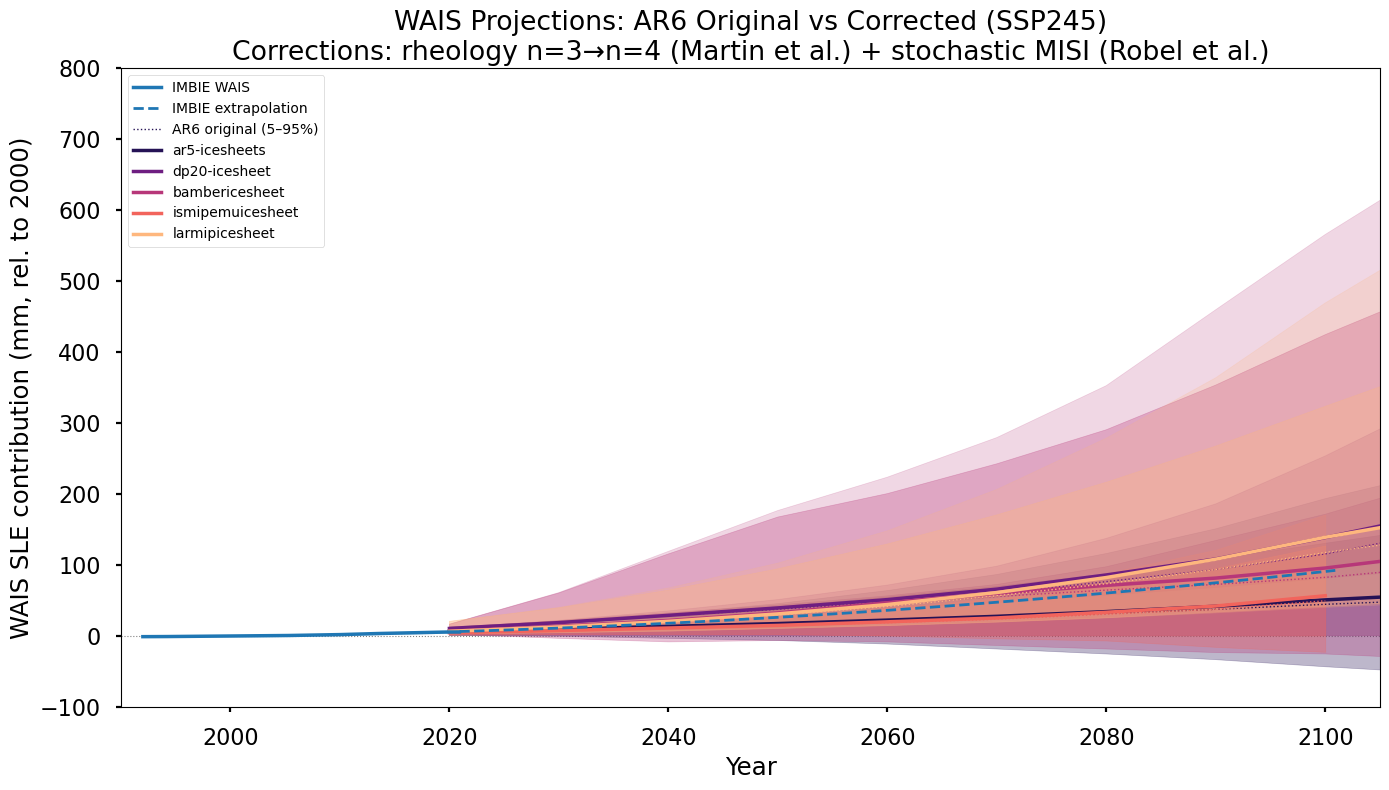

In [8]:
# ── User configuration ──
ssp_show = 'ssp245'

# ── Collect workflows for the selected SSP ──
wfs_to_plot = {wf: data for (wf, ssp), data in ar6_corrected.items() if ssp == ssp_show}
n_wf = len(wfs_to_plot)
print(f'Plotting {n_wf} workflows for {ssp_show}')

# ── Colormap ──
cmap = mpl.colormaps['magma']
wf_colors = [cmap(0.15 + 0.7 * i / max(n_wf - 1, 1)) for i in range(n_wf)]

# ── Figure ──
fig, ax = plt.subplots(figsize=(14, 8))

# 1. IMBIE observations
ax.plot(imbie_time, imbie_sle_mm, color='tab:blue', lw=2.5, label='IMBIE WAIS', zorder=5)
ax.fill_between(imbie_time,
                imbie_sle_mm - 2 * imbie_sigma_mm,
                imbie_sle_mm + 2 * imbie_sigma_mm,
                color='tab:blue', alpha=0.15, zorder=4)

# 2. IMBIE extrapolation
ax.plot(t_extrap, sle_extrap_mm, color='tab:blue', ls='--', lw=2,
        label='IMBIE extrapolation', zorder=4)

# 3. AR6 workflows: original (thin) vs corrected (thick)
for i, (wf, data) in enumerate(sorted(wfs_to_plot.items())):
    years = data['years']
    color = wf_colors[i]
    short = wf.replace('icesheets-', '').replace('ipccar6-', '')

    for tag, samples, lw, alpha in [
        ('original', data['samples_original'], 1.0, 0.3),
        ('corrected', data['samples_corrected'], 2.5, 0.2),
    ]:
        median = np.median(samples, axis=0) + imbie_offset_2005_mm
        p5 = np.percentile(samples, 5, axis=0) + imbie_offset_2005_mm
        p95 = np.percentile(samples, 95, axis=0) + imbie_offset_2005_mm

        ls = ':' if tag == 'original' else '-'
        label = f'{short} ({tag})' if i == 0 or tag == 'corrected' else None
        # Only label original once (first workflow)
        if tag == 'original' and i > 0:
            label = None
        elif tag == 'original' and i == 0:
            label = f'AR6 original (5–95%)'

        ax.plot(years, median, color=color, lw=lw, ls=ls, zorder=3,
               label=f'{short}' if tag == 'corrected' else label)
        ax.fill_between(years, p5, p95, color=color, alpha=alpha, zorder=2)

# ── Formatting ──
ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLE contribution (mm, rel. to 2000)')
ax.set_title(f'WAIS Projections: AR6 Original vs Corrected ({ssp_show.upper()})\n'
             f'Corrections: rheology n=3→n=4 (Martin et al.) + stochastic MISI (Robel et al.)')
ax.axhline(0, color='gray', ls=':', lw=0.8, zorder=1)
ax.set_xlim(1990, 2105)
ax.set_ylim([-100,800])
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()